## Runnable Sequence


In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_core.runnables import RunnableSequence

load_dotenv()

prompt1 = PromptTemplate(
    template='Write a joke about {topic}',
    input_variables=['topic']
)

model = ChatOpenAI()

parser = StrOutputParser()

prompt2 = PromptTemplate(
    template='Explain the following joke - {text}',
    input_variables=['text']
)

chain = RunnableSequence(prompt1, model, parser, prompt2, model, parser)

print(chain.invoke({'topic':'AI'}))

This joke plays on the idea that an AI, being a computer program, is constantly "debugging" or fixing errors in its code. The joke implies that the AI's girlfriend was unable to handle the AI's constant need to work on and improve itself, likening it to a relationship issue where one partner constantly works on self-improvement while the other may find it overwhelming or difficult to keep up with.


## Runnable Parallel

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_core.runnables import RunnableSequence, RunnableParallel

load_dotenv()

prompt1 = PromptTemplate(
    template='Generate a tweet about {topic}',
    input_variables=['topic']
)

prompt2 = PromptTemplate(
    template='Generate a Linkedin post about {topic}',
    input_variables=['topic']
)

model = ChatOpenAI()

parser = StrOutputParser()

parallel_chain = RunnableParallel({
    'tweet': RunnableSequence(prompt1, model, parser),
    'linkedin': RunnableSequence(prompt2, model, parser)
})

result = parallel_chain.invoke({'topic':'AI'})

print(result)


{'tweet': 'Exciting advancements in artificial intelligence are transforming industries and revolutionizing how we work and live. Embracing the power of AI is crucial in staying competitive and driving innovation forward. #AI #technology #innovation.', 'linkedin': 'Exciting times ahead with the advancements in AI technology! From self-driving cars to personalized recommendations, AI is revolutionizing industries and changing the way we live and work. I am thrilled to be a part of this innovative field and look forward to seeing how AI continues to shape the future. #ArtificialIntelligence #Innovation #TechRevolution'}


## Runnable Passthrough

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_core.runnables import RunnableSequence, RunnableParallel, RunnablePassthrough

load_dotenv()

prompt1 = PromptTemplate(
    template='Write a joke about {topic}',
    input_variables=['topic']
)

model = ChatOpenAI()

parser = StrOutputParser()

prompt2 = PromptTemplate(
    template='Explain the following joke - {text}',
    input_variables=['text']
)

joke_gen_chain = RunnableSequence(prompt1, model, parser)

parallel_chain = RunnableParallel({
    'joke': RunnablePassthrough(),
    'explanation': RunnableSequence(prompt2, model, parser)
})

final_chain = RunnableSequence(joke_gen_chain, parallel_chain)

print(final_chain.invoke({'topic':'cricket'}))

{'joke': 'Why did the cricket team go to the bank?\n\nBecause they needed to make a quick withdrawal!', 'explanation': 'This joke is a play on words, as "withdrawal" can mean to take money out of a bank account, but it can also refer to a cricket player being dismissed from the game. In this case, the cricket team went to the bank to make a "quick withdrawal" both in terms of money and getting out of the game quickly.'}


## Runnable Lambda

#### Python function -> Runnable

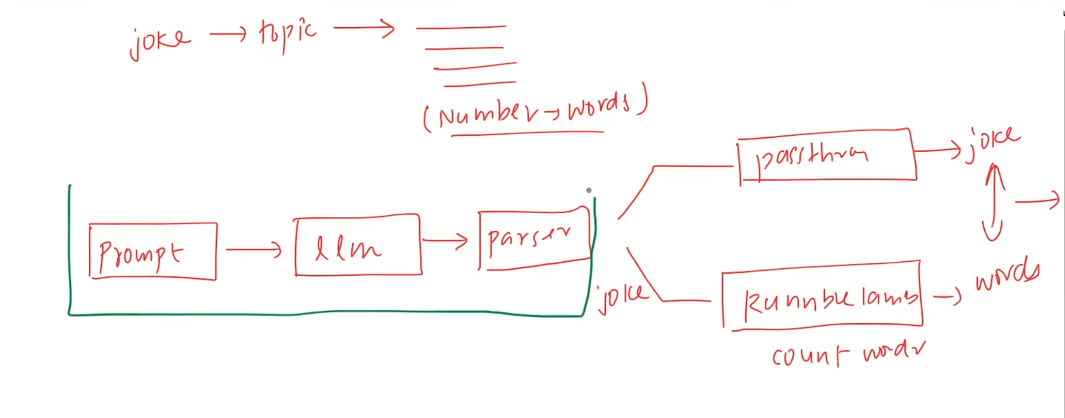

In [7]:
from langchain_core.runnables import RunnableLambda

In [11]:
def wordCount(text):
    return len(text.split())

In [12]:
runnable_wordCount = RunnableLambda(wordCount)

In [13]:
runnable_wordCount.invoke('hi my name is raju joshi')

6

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_core.runnables import RunnableSequence, RunnableLambda, RunnablePassthrough, RunnableParallel

load_dotenv()

def word_count(text):
    return len(text.split())

prompt = PromptTemplate(
    template='Write a joke about {topic}',
    input_variables=['topic']
)

model = ChatOpenAI()

parser = StrOutputParser()

joke_gen_chain = RunnableSequence(prompt, model, parser)

parallel_chain = RunnableParallel({
    'joke': RunnablePassthrough(),
    'word_count': RunnableLambda(word_count)
    # 'word_count': RunnableLambda(lambda x: len(x.split()))
})

final_chain = RunnableSequence(joke_gen_chain, parallel_chain)

result = final_chain.invoke({'topic':'AI'})

final_result = """{} \n word count - {}""".format(result['joke'], result['word_count'])

print(final_result)

Why did the AI break up with its computer? 

Because it found out it was seeing an "older" model! 
 word count - 19


## Runnable Branch

In [15]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain_core.runnables import RunnableSequence, RunnableParallel, RunnablePassthrough, RunnableBranch, RunnableLambda

load_dotenv()

prompt1 = PromptTemplate(
    template='Write a detailed report on {topic}',
    input_variables=['topic']
)

prompt2 = PromptTemplate(
    template='Summarize the following text \n {text}',
    input_variables=['text']
)

model = ChatOpenAI()

parser = StrOutputParser()

report_gen_chain = prompt1 | model | parser

branch_chain = RunnableBranch(
    (lambda x: len(x.split())>300, prompt2 | model | parser),
    RunnablePassthrough()
)

final_chain = RunnableSequence(report_gen_chain, branch_chain)

print(final_chain.invoke({'topic':'Russia vs Ukraine'}))




The conflict between Russia and Ukraine has a long history, with tensions dating back centuries. It began in 2014 when Russia annexed Crimea, leading to a war in eastern Ukraine between Russian-backed separatists and the Ukrainian military. The conflict has resulted in thousands of deaths and displaced millions of people. It has strained relations between Russia and the West, led to sanctions, and heightened tensions with NATO. Despite numerous attempts at negotiation, the fighting continues. The conflict has had a significant impact on Ukraine, causing devastation and displacement. There has been little progress in resolving the underlying issues, and a peaceful resolution is essential to prevent further suffering and instability.


# LCEL

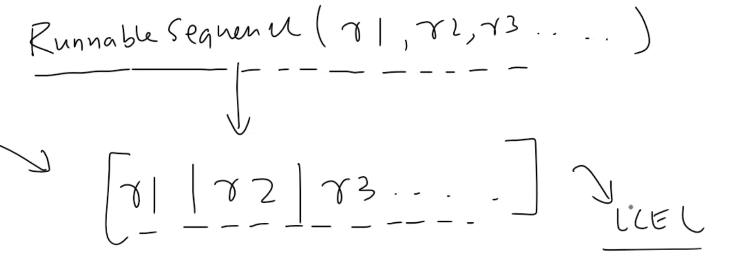